# Digital Image Processing with Python

In this lecture we work through the fundamental techniques of digital image processing,
arranged **from easiest to hardest**:

1. **The basics** — an image is just a NumPy array: changing colours, flipping, cropping and
   resizing (`lotus_leaf.jpg`).
2. **Blurring** — convolution with a Gaussian kernel, computed via the FFT (`elephant.jpg`).
3. **Edge detection** — the Canny detector, and using its contours to segment and count
   objects (`coins.png`).
4. **Denoising in the frequency domain** — we corrupt a photograph of the lunar surface
   (Apollo 17) with noise, then remove the noise by filtering its 2-D FFT
   (`lunar-surface.jpg`).

Each section builds on the previous one: array manipulation gives us the raw material,
convolution is the universal processing tool, edge detection chains convolutions into a
pipeline, and the frequency domain reveals what all these filters are really doing.

## 1. The basics: an image is just an array

A digital colour image is nothing more than a 3-D NumPy array of shape
`(height, width, 3)` — one 2-D grid per **red, green and blue** channel, with `uint8`
values from 0 to 255. Everything we know about NumPy (indexing, slicing, arithmetic)
immediately becomes an image-processing operation.

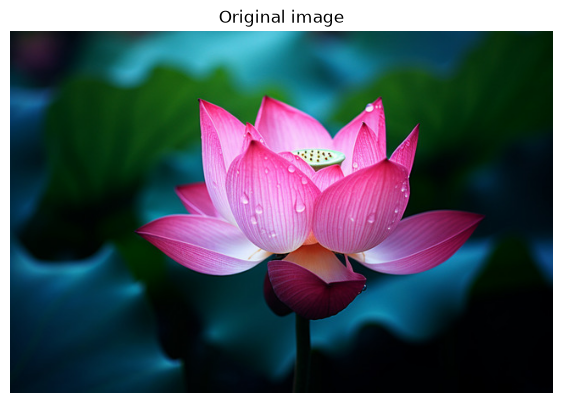

shape = (427, 640, 3)  (height, width, channels)
dtype = uint8, value range = [0, 255]


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

lotus = plt.imread("../../data/img/lotus_leaf.jpg")

plt.figure(figsize=(7, 5))
plt.imshow(lotus)
plt.title("Original image")
plt.axis("off")
plt.show()

print(f"shape = {lotus.shape}  (height, width, channels)")
print(f"dtype = {lotus.dtype}, value range = [{lotus.min()}, {lotus.max()}]")

### The three colour channels

`lotus[:, :, 0]` is the red channel, `[..., 1]` green, `[..., 2]` blue — each a plain 2-D
array. Note how the pink petals are bright in the red channel but dark in the green one.

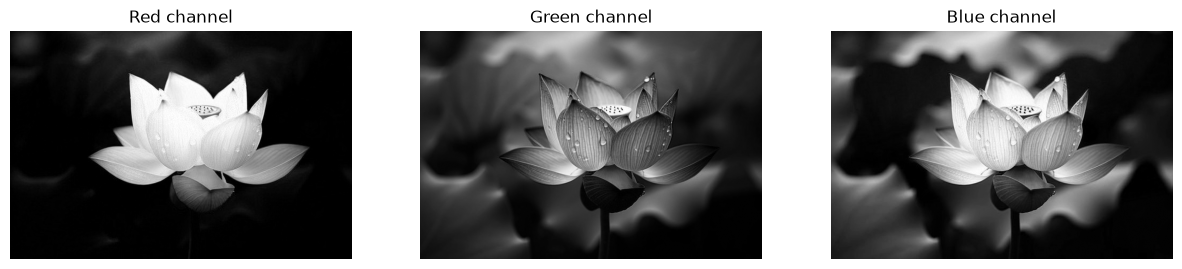

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, name in enumerate(["Red", "Green", "Blue"]):
    axes[i].imshow(lotus[:, :, i], plt.cm.gray)
    axes[i].set_title(f"{name} channel")
    axes[i].axis("off")
plt.show()

### Changing colours

Colour transformations are just arithmetic on the channel axis:

- **swap channels**: reverse the last axis (`[:, :, ::-1]`) turns RGB into BGR;
- **negative**: subtract from the maximum value, `255 - img`;
- **grayscale**: weighted sum of the channels with the standard luminance weights
  $Y = 0.299R + 0.587G + 0.114B$;
- **tinting**: add to a single channel (we must clip to stay inside `[0, 255]`).

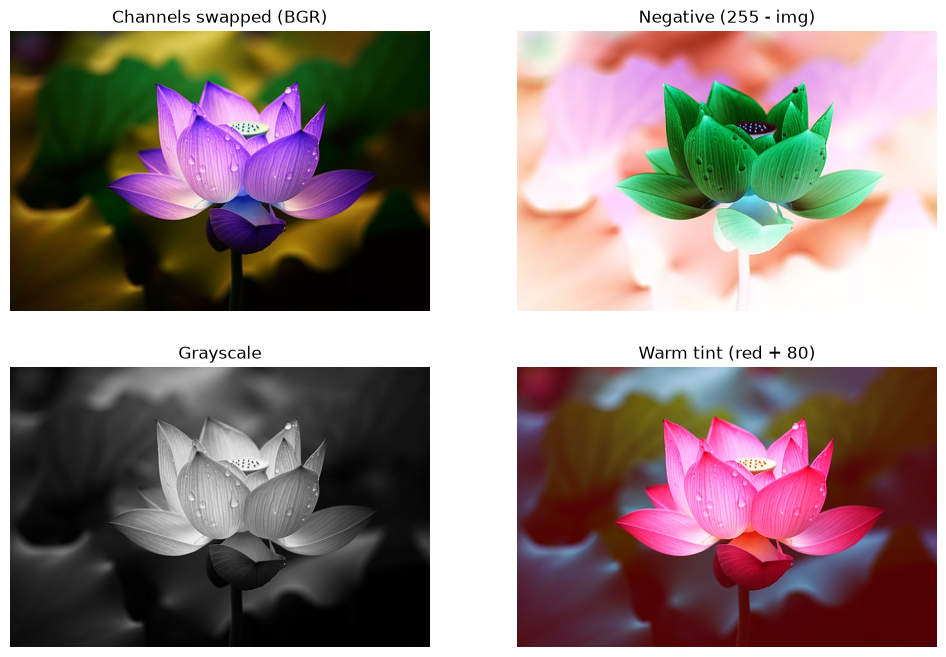

In [3]:
swapped = lotus[:, :, ::-1]              # RGB -> BGR
negative = 255 - lotus                   # photographic negative
gray = lotus @ [0.299, 0.587, 0.114]     # luminance grayscale

warm = lotus.astype(int)                 # int to avoid uint8 overflow
warm[:, :, 0] = np.clip(warm[:, :, 0] + 80, 0, 255)
warm = warm.astype(np.uint8)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(swapped)
axes[0, 0].set_title("Channels swapped (BGR)")
axes[0, 1].imshow(negative)
axes[0, 1].set_title("Negative (255 - img)")
axes[1, 0].imshow(gray, plt.cm.gray)
axes[1, 0].set_title("Grayscale")
axes[1, 1].imshow(warm)
axes[1, 1].set_title("Warm tint (red + 80)")
for ax in axes.flat:
    ax.axis("off")
plt.show()

### Flipping and cropping

Geometric operations on the pixel grid are slicing operations on the array:
reversing an axis flips the image, selecting a sub-range crops it. For rotations by
arbitrary angles, `scipy.ndimage.rotate` interpolates the pixels for us.

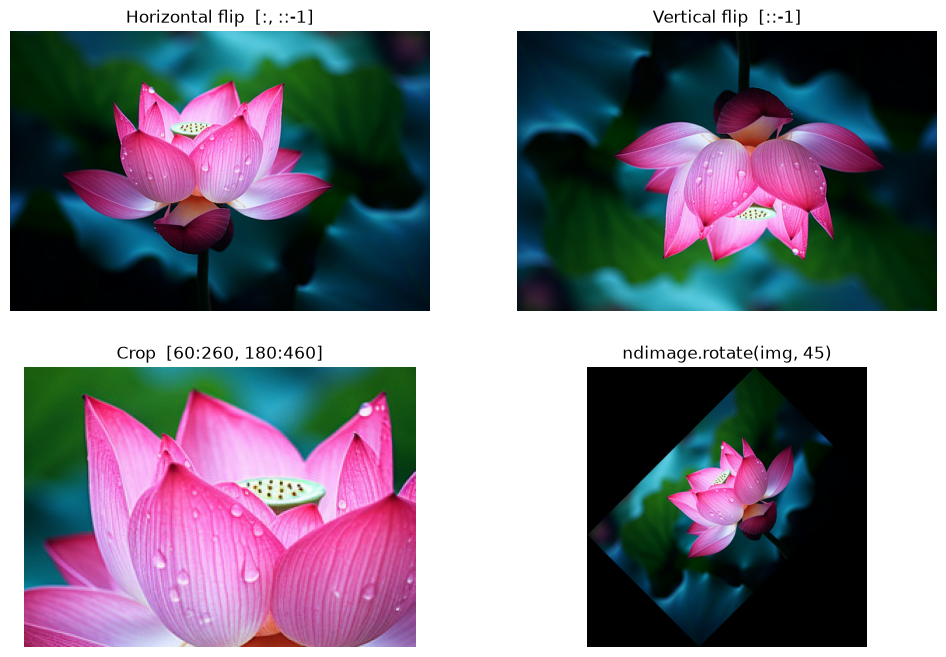

In [4]:
flip_h = lotus[:, ::-1]                  # mirror left-right (= np.fliplr)
flip_v = lotus[::-1]                     # upside down       (= np.flipud)
crop = lotus[60:260, 180:460]            # rows 60-260, columns 180-460
rotated = ndimage.rotate(lotus, 45)      # 45 degrees, with interpolation

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(flip_h)
axes[0, 0].set_title("Horizontal flip  [:, ::-1]")
axes[0, 1].imshow(flip_v)
axes[0, 1].set_title("Vertical flip  [::-1]")
axes[1, 0].imshow(crop)
axes[1, 0].set_title("Crop  [60:260, 180:460]")
axes[1, 1].imshow(rotated)
axes[1, 1].set_title("ndimage.rotate(img, 45)")
for ax in axes.flat:
    ax.axis("off")
plt.show()

### Resizing

Two ways to shrink an image:

- **slicing with a stride** (`[::4, ::4]`) simply throws away 3 of every 4 pixels — fast
  but crude (it can produce jagged *aliasing* artefacts);
- **`ndimage.zoom`** interpolates between pixels, giving a smoother result, and can also
  scale *up*. The zoom factor `(0.25, 0.25, 1)` shrinks height and width but leaves the
  colour axis untouched.

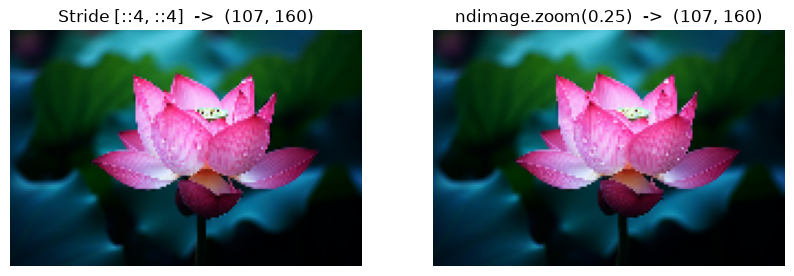

original (427, 640, 3)  ->  resized (107, 160, 3)


In [5]:
strided = lotus[::4, ::4]
zoomed = ndimage.zoom(lotus, (0.25, 0.25, 1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(strided)
axes[0].set_title(f"Stride [::4, ::4]  ->  {strided.shape[:2]}")
axes[1].imshow(zoomed)
axes[1].set_title(f"ndimage.zoom(0.25)  ->  {zoomed.shape[:2]}")
for ax in axes:
    ax.axis("off")
plt.show()

print(f"original {lotus.shape}  ->  resized {zoomed.shape}")

## 2. Simple image blur by convolution with a Gaussian kernel

So far we only moved pixels around. Real processing starts when each output pixel becomes a
**weighted average of its neighbourhood** — a **convolution** with a kernel $K$:

$$f_1(t) = \int dt'\, K(t-t')\, f_0(t')$$

Computing this directly is expensive. The **convolution theorem** offers a shortcut:
in the frequency domain, convolution becomes a simple **multiplication** of the
Fourier transforms,

$$\tilde{f}_1(\omega) = \tilde{K}(\omega)\, \tilde{f}_0(\omega)$$

so the **FFT** turns an expensive convolution into three cheap steps —
*transform, multiply, transform back*. This is why the FFT is one of the workhorses
of image processing.

We blur a colour photograph. Each of the three RGB channels is just a 2-D signal,
so we transform along `axes=(0, 1)` and apply the same kernel to every channel.

First we build the kernel: a 1-D Gaussian bump, normalised so its integral is 1 (a blur
must not change the overall brightness), turned into a 2-D kernel by an outer product.

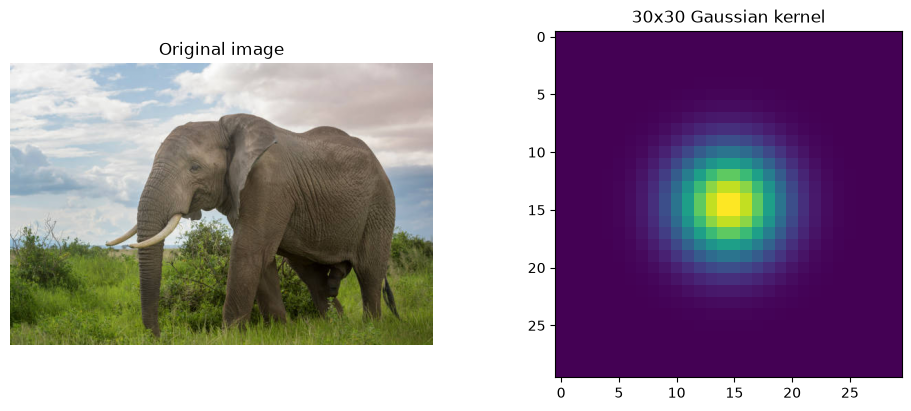

In [6]:
from scipy import fftpack

img = plt.imread("../../data/img/elephant.jpg").astype(float) / 255  # RGB in [0, 1]

# prepare a 1-D Gaussian convolution kernel
t = np.linspace(-10, 10, 30)
bump = np.exp(-0.1 * t**2)
bump /= np.trapezoid(bump)  # normalize the integral to 1

# make a 2-D kernel out of it (outer product)
kernel = bump[:, np.newaxis] * bump[np.newaxis, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(img)
axes[0].set_title("Original image")
axes[0].axis("off")
axes[1].imshow(kernel)
axes[1].set_title("30x30 Gaussian kernel")
plt.show()

### Convolve through the frequency domain

We zero-pad the kernel's FFT to the full image size (`shape=img.shape[:2]`), multiply the two
spectra, and transform back. Note the `[:, :, np.newaxis]`: it broadcasts the 2-D kernel spectrum
over the three colour channels, so each channel is blurred with the same kernel.

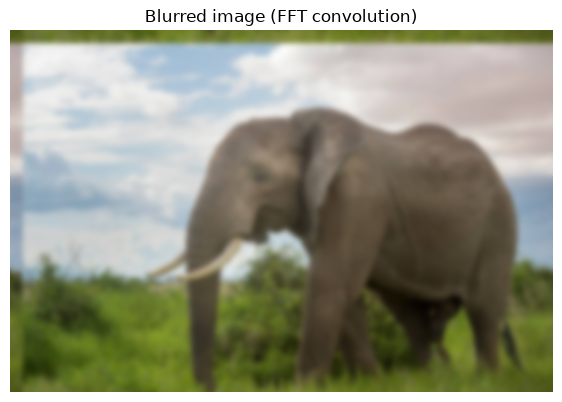

In [7]:
# padded fourier transform, with the same shape as the image
kernel_ft = fftpack.fft2(kernel, shape=img.shape[:2], axes=(0, 1))

# convolve: multiplication in the frequency domain
img_ft = fftpack.fft2(img, axes=(0, 1))
img2_ft = kernel_ft[:, :, np.newaxis] * img_ft
img2 = fftpack.ifft2(img2_ft, axes=(0, 1)).real

# clip values to the valid display range
img2 = np.clip(img2, 0, 1)

plt.figure(figsize=(7, 5))
plt.imshow(img2)
plt.title("Blurred image (FFT convolution)")
plt.axis("off")
plt.show()

Look closely at the top edge of the result: a thin strip of grass has **wrapped around** from the
bottom of the picture, and the whole image is shifted slightly down-and-right. The FFT treats the
image as *periodic*, and our kernel is not centred at the origin — these boundary effects are the
price of the naive approach.

In practice we use `scipy.signal.fftconvolve`, which performs the same FFT trick but handles the
zero-padding and kernel alignment for us:

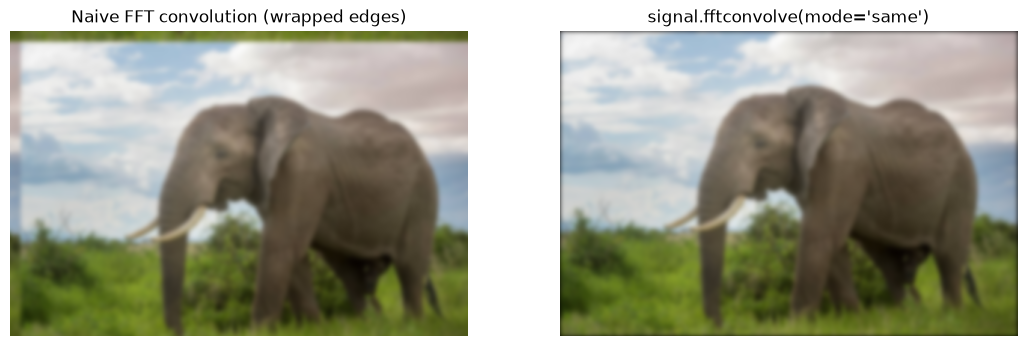

In [8]:
from scipy import signal

# mode='same' returns an output of the same size as the image
img3 = signal.fftconvolve(img, kernel[:, :, np.newaxis], mode="same")
img3 = np.clip(img3, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(img2)
axes[0].set_title("Naive FFT convolution (wrapped edges)")
axes[1].imshow(img3)
axes[1].set_title("signal.fftconvolve(mode='same')")
for ax in axes:
    ax.axis("off")
plt.show()

## 3. Canny edge detection

Blurring removes the fine detail; **edge detection** is the opposite task: find exactly the
places where intensity changes abruptly — the outlines of objects.

The classic algorithm is the **Canny edge detector** (1986). It chains together ideas we
have already met:

1. **Gaussian smoothing** — suppress noise first (otherwise every noisy pixel looks like an edge);
2. **Gradient** — measure the intensity change with Sobel derivative filters (a convolution!);
3. **Non-maximum suppression** — thin the result to 1-pixel-wide ridges along the gradient direction;
4. **Hysteresis thresholding** — keep strong edges, and weak edges only if connected to a strong one.

We demonstrate on a grayscale photograph of coins, starting with the raw gradient magnitude from
step 2 to see why the later steps are needed.

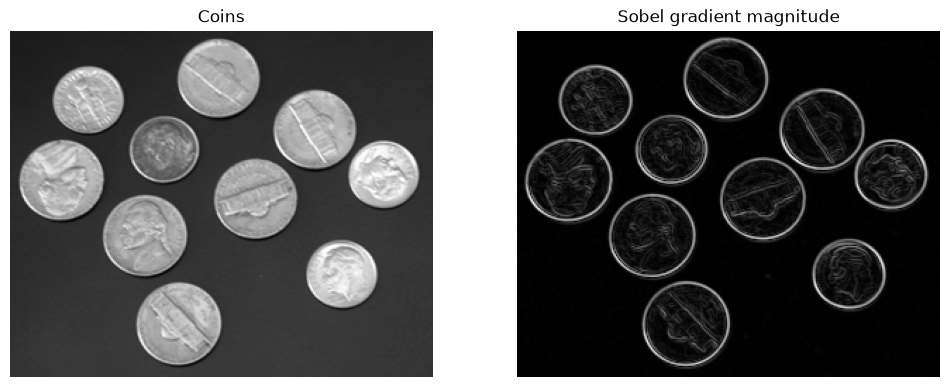

shape = (246, 300), intensity range = [0.09, 1.00]


In [9]:
from skimage import feature, filters

coins = plt.imread("../../data/img/coins.png")  # already grayscale, values in [0, 1]

grad = filters.sobel(coins)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(coins, plt.cm.gray)
axes[0].set_title("Coins")
axes[1].imshow(grad, plt.cm.gray)
axes[1].set_title("Sobel gradient magnitude")
for ax in axes:
    ax.axis("off")
plt.show()

print(f"shape = {coins.shape}, intensity range = [{coins.min():.2f}, {coins.max():.2f}]")

The Sobel map shows *how strong* the intensity change is at every pixel, but the lines are thick and
faint edges mix with strong ones. Canny turns this into crisp one-pixel contours. The `sigma`
parameter is the width of the Gaussian smoothing in step 1 — it decides *which scale* of edges
survives:

- **small `sigma`** keeps fine detail (the engraving on each coin) but also noise;
- **large `sigma`** suppresses texture and keeps only the dominant outlines.

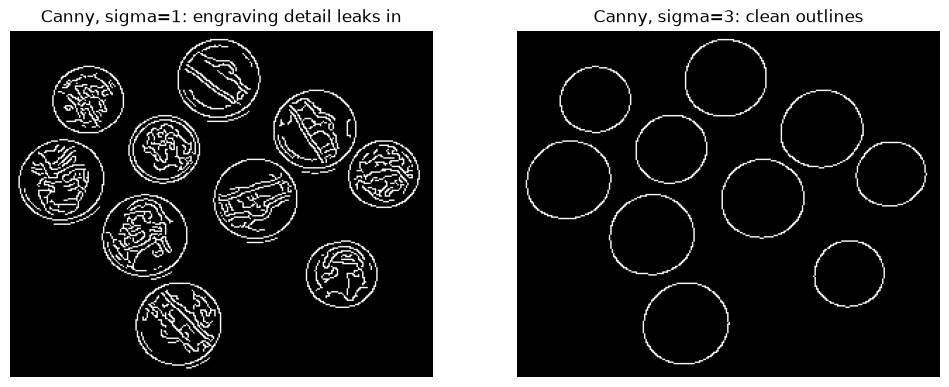

In [10]:
edges1 = feature.canny(coins, sigma=1)
edges2 = feature.canny(coins, sigma=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(edges1, plt.cm.gray)
axes[0].set_title("Canny, sigma=1: engraving detail leaks in")
axes[1].imshow(edges2, plt.cm.gray)
axes[1].set_title("Canny, sigma=3: clean outlines")
for ax in axes:
    ax.axis("off")
plt.show()

### From edges to objects: counting the coins

Clean closed contours are the entry point to **segmentation**. We fill the area enclosed by each
edge contour with `ndimage.binary_fill_holes`, then let `ndimage.label` assign a number to every
connected region — which counts the coins for us:

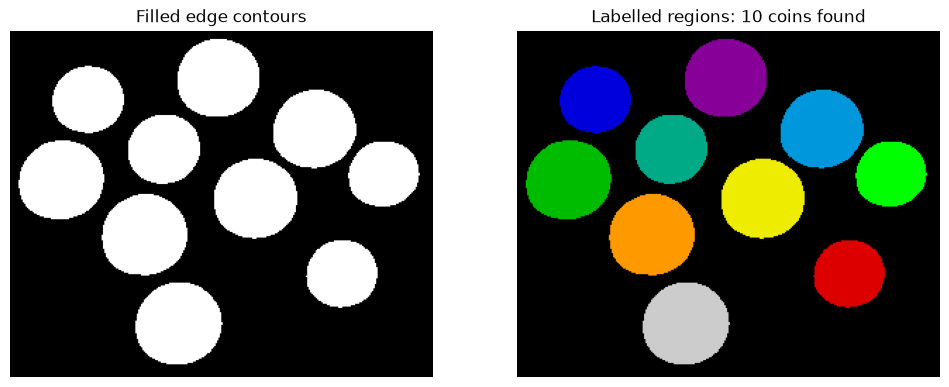

Number of coins detected: 10


In [11]:
# Fill the area enclosed by the edges, then label the connected regions
fill_coins = ndimage.binary_fill_holes(edges2)
label_coins, n_coins = ndimage.label(fill_coins)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(fill_coins, plt.cm.gray)
axes[0].set_title("Filled edge contours")
axes[1].imshow(label_coins, plt.cm.nipy_spectral)
axes[1].set_title(f"Labelled regions: {n_coins} coins found")
for ax in axes:
    ax.axis("off")
plt.show()

print(f"Number of coins detected: {n_coins}")

## 4. Image denoising in the frequency domain

Our final and most advanced topic puts the FFT itself at centre stage.

An image is a 2-D signal, and the 2-D FFT decomposes it into a sum of sinusoidal patterns of
different **spatial frequencies**:

- **Low frequencies** (slow variations) carry the overall shapes and smooth shading.
- **High frequencies** (fast variations) carry fine detail, sharp edges — and most kinds of noise.

If noise and image content live at *different* frequencies, we can separate them: transform,
erase the offending frequencies, transform back. We demonstrate the full workflow by corrupting
a clean photograph of the lunar surface (Apollo 17) and then recovering it.

### 4.1 Read and plot the original image

We convert the photo to grayscale with the luminance weights from section 1, since the demo
works on a single 2-D channel.

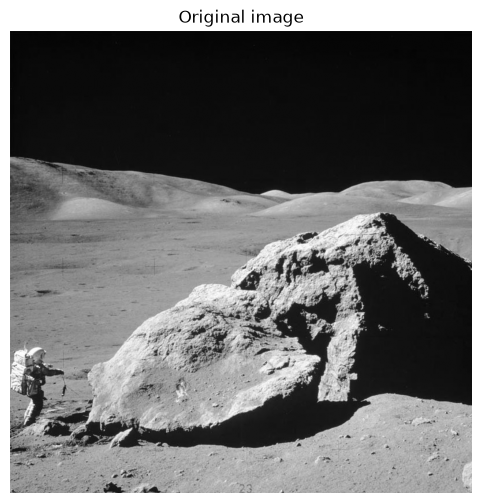

shape = (800, 800), intensity range = [4.3, 255.0]


In [12]:
rgb = plt.imread("../../data/img/lunar-surface.jpg").astype(float)
im = rgb @ [0.299, 0.587, 0.114]  # RGB -> grayscale luminance

plt.figure(figsize=(6, 6))
plt.imshow(im, plt.cm.gray)
plt.title("Original image")
plt.axis("off")
plt.show()

print(f"shape = {im.shape}, intensity range = [{im.min():.1f}, {im.max():.1f}]")

### 4.2 Make a noisy image

Real images get corrupted in two typical ways, and we simulate both:

1. **Periodic interference** — e.g. electrical interference in a scanner or transmission line.
   We add two sinusoidal patterns (vertical and horizontal stripes). This is exactly the kind of noise
   that plagued early scanned photographs such as the famous `moonlanding.png`.
2. **Random (Gaussian) noise** — e.g. sensor noise in low light.

The key property: the periodic noise is concentrated at **specific high frequencies**
(120 cycles across and 150 cycles down), far away from where the image content lives.

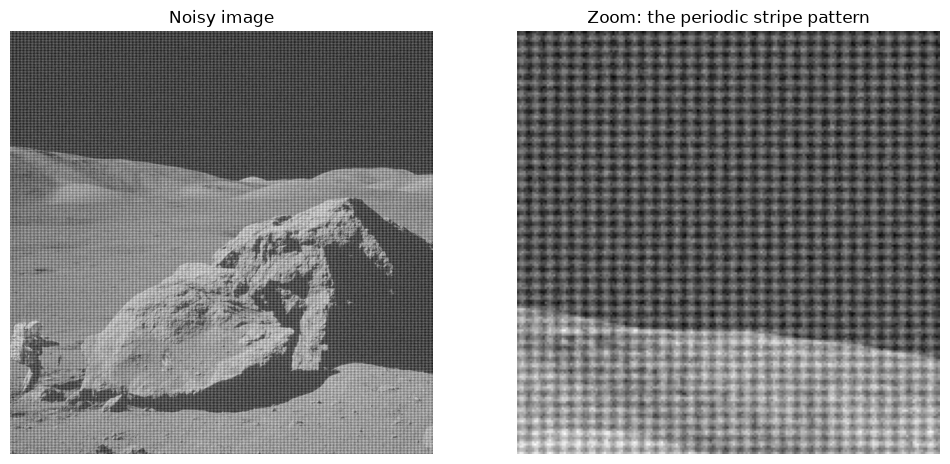

In [13]:
rng = np.random.default_rng(42)
r, c = im.shape
y, x = np.mgrid[0:r, 0:c]

# Periodic interference: 120 cycles horizontally + 150 cycles vertically
periodic_noise = 40 * np.sin(2 * np.pi * x * 120 / c) + 40 * np.sin(2 * np.pi * y * 150 / r)

# Random sensor noise
gaussian_noise = rng.normal(0, 15, im.shape)

im_noisy = im + periodic_noise + gaussian_noise

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(im_noisy, plt.cm.gray)
axes[0].set_title("Noisy image")
axes[0].axis("off")
axes[1].imshow(im_noisy[100:300, 100:300], plt.cm.gray)
axes[1].set_title("Zoom: the periodic stripe pattern")
axes[1].axis("off")
plt.show()

### 4.3 Compute the 2-D FFT of the noisy image

`fftpack.fft2` returns a complex array of Fourier coefficients. We visualise its **magnitude spectrum**
on a logarithmic colour scale (the dynamic range is huge — the DC component dominates everything).

In NumPy/SciPy's FFT layout the **low frequencies sit in the four corners** of the array.
We also show the `fftshift`-ed version with the low frequencies moved to the centre, which is
easier to read: the four bright **isolated spikes** are our periodic noise!

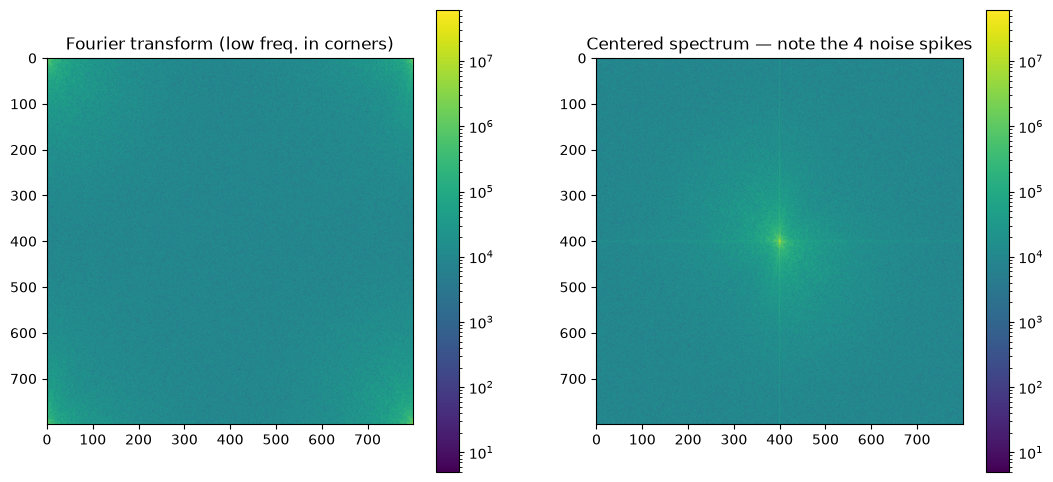

In [14]:
from matplotlib.colors import LogNorm

im_fft = fftpack.fft2(im_noisy)


def plot_spectrum(im_fft):
    # A logarithmic colormap
    plt.imshow(np.abs(im_fft), norm=LogNorm(vmin=5))
    plt.colorbar()


plt.figure(figsize=(13, 6))
plt.subplot(1, 2, 1)
plot_spectrum(im_fft)
plt.title("Fourier transform (low freq. in corners)")
plt.subplot(1, 2, 2)
plot_spectrum(fftpack.fftshift(im_fft))
plt.title("Centered spectrum — note the 4 noise spikes")
plt.show()

### 4.4 Filter in the frequency domain

Now the denoising step. The image content is concentrated in the low frequencies, while the periodic
noise sits at high frequencies. So we apply a crude **low-pass filter**: keep only a fraction of the
coefficients in each direction and zero out everything else.

With `keep_fraction = 0.1` we keep the lowest 10% of frequencies along rows and columns —
the noise spikes at 120 and 150 cycles lie well outside the kept band (indices < 80), so they are erased.

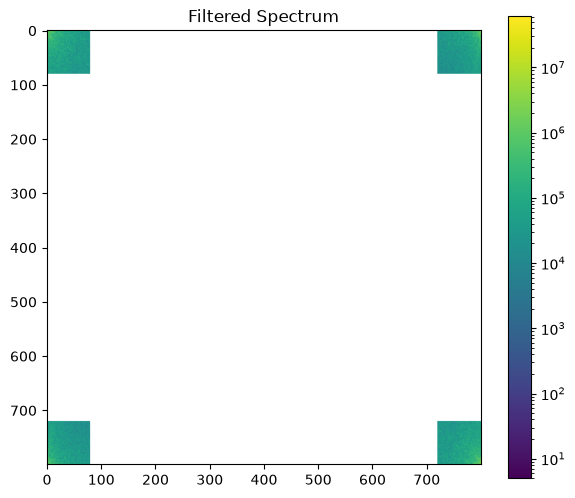

In [15]:
# Define the fraction of coefficients (in each direction) we keep
keep_fraction = 0.1

# Make a copy of the original transform. Numpy arrays have a copy method for this purpose.
im_fft2 = im_fft.copy()

# Set r and c to be the number of rows and columns of the array.
r, c = im_fft2.shape

# Set to zero all rows with indices between r*keep_fraction and r*(1-keep_fraction):
im_fft2[int(r * keep_fraction) : int(r * (1 - keep_fraction))] = 0

# Similarly with the columns:
im_fft2[:, int(c * keep_fraction) : int(c * (1 - keep_fraction))] = 0

plt.figure(figsize=(7, 6))
plot_spectrum(im_fft2)
plt.title("Filtered Spectrum")
plt.show()

### 4.5 Reconstruct the denoised image

The inverse FFT (`ifft2`) takes us back to the spatial domain. The result is complex with a tiny
imaginary part due to floating-point round-off, so we keep only the real part for display.

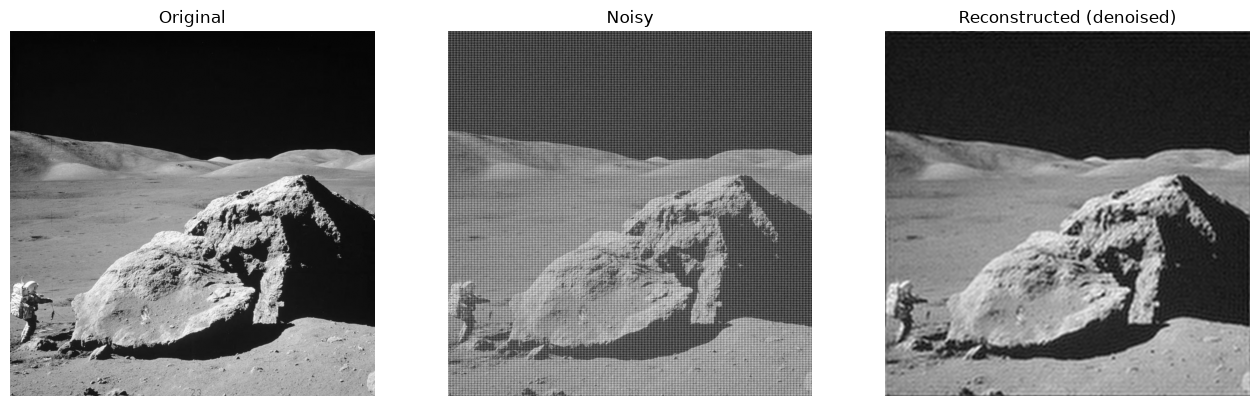

Mean absolute error vs. original —  noisy: 34.82,  denoised: 8.34


In [16]:
im_new = fftpack.ifft2(im_fft2).real

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(im, plt.cm.gray)
axes[0].set_title("Original")
axes[1].imshow(im_noisy, plt.cm.gray)
axes[1].set_title("Noisy")
axes[2].imshow(im_new, plt.cm.gray)
axes[2].set_title("Reconstructed (denoised)")
for ax in axes:
    ax.axis("off")
plt.show()

print(f"Mean absolute error vs. original —  noisy: {np.abs(im_noisy - im).mean():.2f},"
      f"  denoised: {np.abs(im_new - im).mean():.2f}")

The periodic stripes are completely gone and the random noise is strongly reduced — the error drops
by roughly a factor of four. The price we pay is some loss of fine detail (a slight blur and faint
ringing near sharp edges), because our brutal rectangular cut-off also removed the image's own
high-frequency content.

### 4.6 Easier and better: `scipy.ndimage.gaussian_filter`

Implementing filtering directly with FFTs is tricky and time consuming. For a plain smoothing/blur,
we can simply use the Gaussian filter from `scipy.ndimage`, which performs the convolution for us.

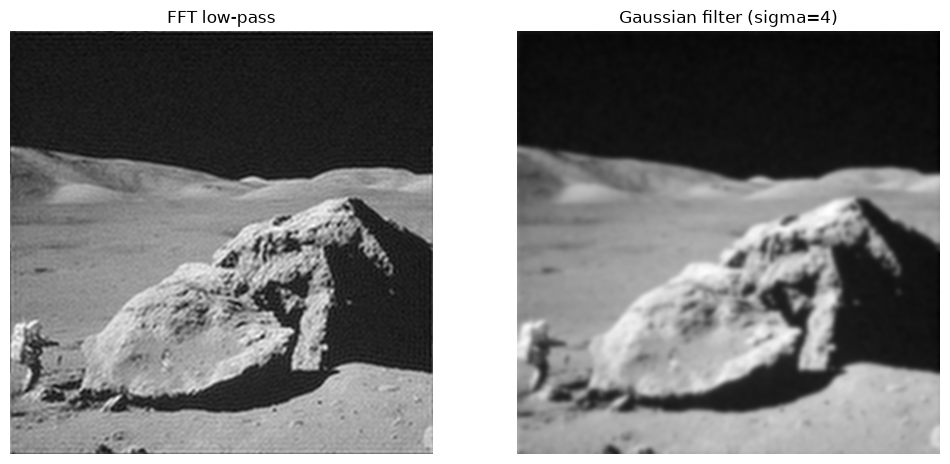

Mean absolute error vs. original —  gaussian_filter: 9.25


In [17]:
im_blur = ndimage.gaussian_filter(im_noisy, 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(im_new, plt.cm.gray)
axes[0].set_title("FFT low-pass")
axes[1].imshow(im_blur, plt.cm.gray)
axes[1].set_title("Gaussian filter (sigma=4)")
for ax in axes:
    ax.axis("off")
plt.show()

print(f"Mean absolute error vs. original —  gaussian_filter: {np.abs(im_blur - im).mean():.2f}")

## Summary

| Topic | Operation | Function |
|---|---|---|
| 1 | Colours, flips, crops are array operations | indexing & slicing |
| 1 | Resize / rotate with interpolation | `ndimage.zoom`, `ndimage.rotate` |
| 2 | Blur = convolution = multiplication of spectra | `signal.fftconvolve` |
| 3 | Detect edges (smooth → gradient → thin → threshold) | `skimage.feature.canny` |
| 3 | Segment and count objects from closed contours | `ndimage.binary_fill_holes` + `ndimage.label` |
| 4 | Transform image to frequency domain and back | `fftpack.fft2`, `fftpack.ifft2(...).real` |
| 4 | Inspect the magnitude spectrum (log scale) | `np.abs` + `LogNorm` |
| 4 | Zero out unwanted (high) frequencies | array slicing |

**Key takeaways**

- An image is a NumPy array: colour changes, flips, crops and resizes are one-line array
  operations — no special machinery needed.
- By the convolution theorem, multiplying spectra equals convolving images — the FFT makes large
  convolutions fast ($O(N \log N)$ instead of $O(N^2)$). A Gaussian blur is exactly such a
  convolution, and `scipy.signal.fftconvolve` packages the whole trick in one call.
- The naive FFT convolution assumes a periodic image, producing wrap-around artefacts at the edges;
  library routines handle the padding for you.
- Edges are the high-frequency content: the Canny detector first *smooths* (Gaussian), then
  *differentiates* (Sobel convolution) — the same building blocks, recombined. Its `sigma` selects
  the scale of edges to keep, and clean closed contours open the door to segmentation.
- Periodic noise appears as isolated **spikes** in the spectrum, so the frequency domain is the
  natural place to remove it — nearly impossible to do well in the spatial domain.
- A low-pass filter trades noise for detail: the harder you cut, the smoother (blurrier) the result.

**Exercises**

1. *(Basics)* Rotate the lotus image by 90° using **only array operations** (hint: transpose + flip).
   Then make the image more blue instead of more red.
2. *(Blur)* Widen the kernel (e.g. `np.exp(-0.02 * t**2)`). How does the blur change,
   and what does that correspond to in the frequency domain?
3. *(Edges)* Run the Canny detector with `sigma=5`. How many coins does the pipeline count now,
   and why?
4. *(Denoise)* Change `keep_fraction` to 0.05 and 0.3. What happens to the noise and to the sharpness?
5. *(Denoise)* Instead of the rectangular low-pass, zero out **only the four noise spikes**
   (a *notch filter*) and reconstruct. How does the result compare?
6. *(Denoise)* Lower the noise frequencies to 50 cycles. Why does the `keep_fraction = 0.1`
   filter stop working?
7. *(Combined)* Chain the pipeline: denoise the lunar image first, then run Canny edge detection
   on the result. What happens if you skip the denoising step?